In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def mostrar_tablero(tablero):
    for fila in range(len(tablero)):
        linea = ""
        for col in range(len(tablero)):
            if tablero[fila][col] == 1:
                linea += " Q "
            else:
                linea += " . "
        print(linea)
    print("\n")

In [3]:
# tamaño del tablero
n = 8

In [4]:
def es_valido(tablero, fila, col):
    n = len(tablero)
    for i in range(fila):
        for j in range(n):
            if tablero[i][j] == 1:
                if j == col or abs(j - col) == abs(i - fila):
                    return False
    return True

def backtracking(tablero, fila, recursive_call, backtrack):
    if fila == len(tablero):
        return tablero, recursive_call, backtrack 
    
    for i in range(len(tablero)):
        if es_valido(tablero, fila, i):
            tablero[fila][i] = 1
            resultado, recursive_call, backtrack = backtracking(tablero, fila + 1, recursive_call + 1, backtrack)
            if resultado:
                return resultado, recursive_call, backtrack
            tablero[fila][i] = 0
            backtrack += 1  # Incrementar backtrack cuando se deshace una asignación
    return None, recursive_call, backtrack


print("Solución con Backtracking:")
tablero = [[0]*n for _ in range(n)]
t0 = time.time()*1000000
resultado_backtracking, recursive_call, backtrack = backtracking(tablero, 0, 1, 0)  # 1 para contar la llamada inicial
t1 = time.time()*1000000
ejecucion = (t1 - t0) / 1000  # Convertir a milisegundos
mostrar_tablero(resultado_backtracking if resultado_backtracking else tablero)
print(f"Tiempo de ejecución: {ejecucion:.4f} milisegundos")
print(f"Número de llamadas recursivas: {recursive_call}")
print(f"Número de backtracks: {backtrack}")

Solución con Backtracking:
 Q  .  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  .  .  .  Q  .  . 
 .  .  Q  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  Q  .  .  .  . 


Tiempo de ejecución: 1.1675 milisegundos
Número de llamadas recursivas: 114
Número de backtracks: 105


In [5]:
def experimento_backtracking():
    import numpy as np  # Para usar np.mean
    REPETICIONES = 4
    N = [8, 10, 12, 20]
    resultados = {
        "algoritmo": [],
        "n": [],
        "tiempo (ms)": [],
        "llamadas": [],
        "backtracks": []
    }
    for n in N:
        tiempos = []
        llamadas = []
        backtracks_lista = []
        tablero = [[0]*n for _ in range(n)]
        for _ in range(REPETICIONES):
            t0 = time.time()*1000000
            # Guardamos la referencia original de la función backtracking
            resultado_bt, recursive_call, backtrack = backtracking(tablero, 0, 1, 0)
            t1 = time.time()*1000000
            ejecucion = (t1 - t0) / 1000
            tiempos.append(ejecucion)
            llamadas.append(recursive_call)
            backtracks_lista.append(backtrack)
        resultados["algoritmo"].append("backtracking")
        resultados["n"].append(n)
        resultados["tiempo (ms)"].append(sum(tiempos)/len(tiempos))
        resultados["llamadas"].append(sum(llamadas)/len(llamadas))
        resultados["backtracks"].append(sum(backtracks_lista)/len(backtracks_lista))
    return resultados

# Llamar a la función y guardar el resultado en una variable para evitar sobrescribir la función backtracking
ex = time.time()
resultados_experimento = experimento_backtracking()
print(time.time() - ex)

23.798924922943115


In [6]:
def forward_checking(tablero, fila, dominios, recursive_call, backtrack):
    n = len(tablero)

    if fila == n:
        return tablero, recursive_call, backtrack

    for col in dominios[fila][:]:
        tablero[fila][col] = 1
        nuevos = {f: list(dominios[f]) for f in dominios}
        for f in range(fila + 1, n):
            if col in nuevos[f]:
                nuevos[f].remove(col)
            diag1 = col + (f -fila)
            diag2 = col - (f -fila)
            if diag1 in nuevos[f]:
                nuevos[f].remove(diag1)
            if diag2 in nuevos[f]:
                nuevos[f].remove(diag2) 

        if any(len(nuevos[f]) == 0 for f in range(fila + 1, n)):
            tablero[fila][col] = 0
            backtrack += 1  # Incrementar backtrack cuando se detecta un dominio vacío
            continue

        resultado, recursive_call, backtrack = forward_checking(tablero, fila+1, nuevos, recursive_call + 1, backtrack)
        if resultado: 
            return resultado, recursive_call, backtrack

        tablero[fila][col] = 0
        backtrack += 1  # Incrementar backtrack cuando se deshace una asignación

    return None, recursive_call, backtrack

print("Solución con Forward Checking:")
tablero = [[0]*n for _ in range(n)]
t0 = time.time() * 1000000
resultado_fch, recursive_call, backtrack = forward_checking(tablero, 0, {i: list(range(n)) for i in range(n)}, 1, 0)  # 1 para contar la llamada inicial
t1 = time.time() * 1000000
ejecucion = (t1 - t0) / 1000  # Convertir a milisegundos
mostrar_tablero(resultado_fch if resultado_fch else tablero)
print(f"Tiempo de ejecución: {ejecucion:.4f} milisegundos")
print(f"Número de llamadas recursivas: {recursive_call}")
print(f"Número de backtracks: {backtrack}")

Solución con Forward Checking:
 Q  .  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  .  .  .  Q  .  . 
 .  .  Q  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  Q  .  .  .  . 


Tiempo de ejecución: 0.4908 milisegundos
Número de llamadas recursivas: 54
Número de backtracks: 80


In [7]:
def experimento_forward_checking():
    REPETICIONES = 4
    N = [8, 10, 12, 20]
    resultados = {
        "algoritmo": [],
        "n": [],
        "tiempo (ms)": [],
        "llamadas": [],
        "backtracks": []
    }
    for n in N:
        tiempos = []
        llamadas = []
        backtracks_lista = []
        tablero = [[0]*n for _ in range(n)]
        for _ in range(REPETICIONES):
            t0 = time.time()*1000000
            resultado_fch, recursive_call, backtrack = forward_checking(tablero, 0, {i: list(range(n)) for i in range(n)}, 1, 0)
            t1 = time.time()*1000000
            ejecucion = (t1 - t0) / 1000
            tiempos.append(ejecucion)
            llamadas.append(recursive_call)
            backtracks_lista.append(backtrack)
        resultados["algoritmo"].append("forward_checking")
        resultados["n"].append(n)
        resultados["tiempo (ms)"].append(sum(tiempos)/len(tiempos))
        resultados["llamadas"].append(sum(llamadas)/len(llamadas))
        resultados["backtracks"].append(sum(backtracks_lista)/len(backtracks_lista))
    return resultados

ex = time.time()
resultados_experimento_forward_checking = experimento_forward_checking()
print(time.time() - ex)
    

3.608323812484741


In [8]:
def forward_checking_MRV(tablero, dominios, restantes, recursive_call, backtrack):
    if not restantes:
        return [row[:] for row in tablero], recursive_call, backtrack

    fila = min(restantes, key=lambda x: len(dominios[x]))
        
    for col in dominios[fila][:]:
        tablero[fila][col] = 1
        nuevos = {f: list(dominios[f]) for f in dominios}
        for f in restantes - {fila}:
            if col in nuevos[f]:
                nuevos[f].remove(col)
            diag1 = col + (f -fila)
            diag2 = col - (f -fila)
            if diag1 in nuevos[f]:
                nuevos[f].remove(diag1)
            if diag2 in nuevos[f]:
                nuevos[f].remove(diag2) 

        if any(len(nuevos[f]) == 0 for f in restantes - {fila}):
            tablero[fila][col] = 0
            backtrack += 1  # Incrementar backtrack cuando se detecta un dominio vacío
            continue

        resultado, recursive_call, backtrack = forward_checking_MRV(tablero, nuevos, restantes - {fila}, recursive_call + 1, backtrack)
        if resultado: 
            return resultado, recursive_call, backtrack

        tablero[fila][col] = 0
        backtrack += 1  # Incrementar backtrack cuando se deshace una asignación

    return None, recursive_call, backtrack

print("Solución con Forward Checking y MRV:")
tablero = [[0]*n for _ in range(n)]
t0 = time.time() * 1000000
resultado_fchMRV, recursive_call, backtrack = forward_checking_MRV(tablero, {i: list(range(n)) for i in range(n)}, set(range(n)), 1, 0)  # 1 para contar la llamada inicial
t1 = time.time() * 1000000
ejecucion = (t1 - t0) / 1000  # Convertir a milisegundos
mostrar_tablero(resultado_fchMRV if resultado_fchMRV else tablero)
print(f"Tiempo de ejecución: {ejecucion:.4f} milisegundos")
print(f"Número de llamadas recursivas: {recursive_call}")
print(f"Número de backtracks: {backtrack}")


Solución con Forward Checking y MRV:
 Q  .  .  .  .  .  .  . 
 .  .  .  .  Q  .  .  . 
 .  .  .  .  .  .  .  Q 
 .  .  .  .  .  Q  .  . 
 .  .  Q  .  .  .  .  . 
 .  .  .  .  .  .  Q  . 
 .  Q  .  .  .  .  .  . 
 .  .  .  Q  .  .  .  . 


Tiempo de ejecución: 0.5417 milisegundos
Número de llamadas recursivas: 53
Número de backtracks: 67


In [9]:
def experimento_forward_checking_MRV():
    import numpy as np  # Para usar np.mean
    REPETICIONES = 4
    N = [8, 10, 12, 20, 50]
    resultados = {
        "algoritmo": [], 
        "n": [],
        "tiempo (ms)": [],
        "llamadas": [],
        "backtracks": []
    }
    for n in N:
        tiempos = []
        llamadas = []
        backtracks_lista = []
        tablero = [[0]*n for _ in range(n)]
        for _ in range(REPETICIONES):
            t0 = time.time()*1000000
            resultado_fch_MRV, recursive_call, backtrack = forward_checking_MRV(tablero, {i: list(range(n)) for i in range(n)}, set(range(n)), 1, 0)
            t1 = time.time()*1000000
            ejecucion = (t1 - t0) / 1000
            tiempos.append(ejecucion)
            llamadas.append(recursive_call)
            backtracks_lista.append(backtrack)
        resultados["algoritmo"].append("forward_checking_MRV")
        resultados["n"].append(n)
        resultados["tiempo (ms)"].append(sum(tiempos)/len(tiempos))
        resultados["llamadas"].append(sum(llamadas)/len(llamadas))
        resultados["backtracks"].append(sum(backtracks_lista)/len(backtracks_lista))
    return resultados

ex = time.time()
resultados_experimento_forward_checking_MRV = experimento_forward_checking_MRV()
print(time.time() - ex)

0.1843407154083252


In [10]:
temp_df0 = pd.DataFrame(resultados_experimento_forward_checking_MRV)


In [11]:
temp_df1 = pd.DataFrame(resultados_experimento_forward_checking)

In [12]:
temp_df2 = pd.DataFrame(resultados_experimento)

In [13]:
dfResultados = pd.concat([temp_df0, temp_df1, temp_df2])

In [14]:
dfResultados

,algoritmo,n,tiempo (ms),llamadas,backtracks
0,forward_checking_MRV,8,0.404250,53.00,67.00
1,forward_checking_MRV,10,0.404438,27.00,25.00
2,forward_checking_MRV,12,1.052375,108.00,142.00
3,forward_checking_MRV,20,1.681125,115.00,127.00
4,forward_checking_MRV,50,42.466125,1565.00,2019.00
0,forward_checking,8,0.347250,54.00,80.00
1,forward_checking,10,0.416312,54.00,73.00
2,forward_checking,12,0.956937,112.00,181.00
3,forward_checking,20,900.299250,84401.00,145131.00
0,backtracking,8,0.718437,68.25,59.25


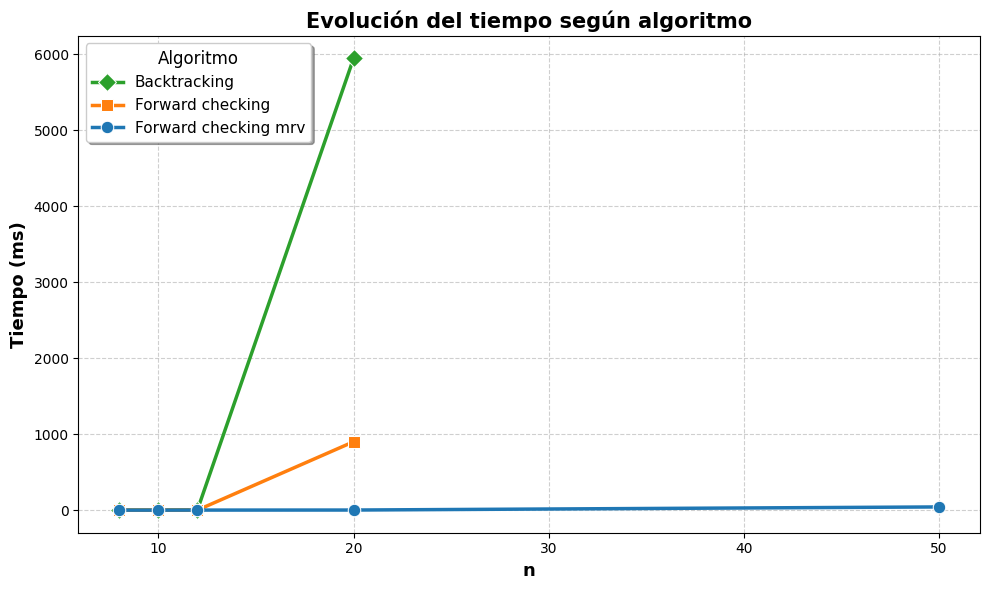

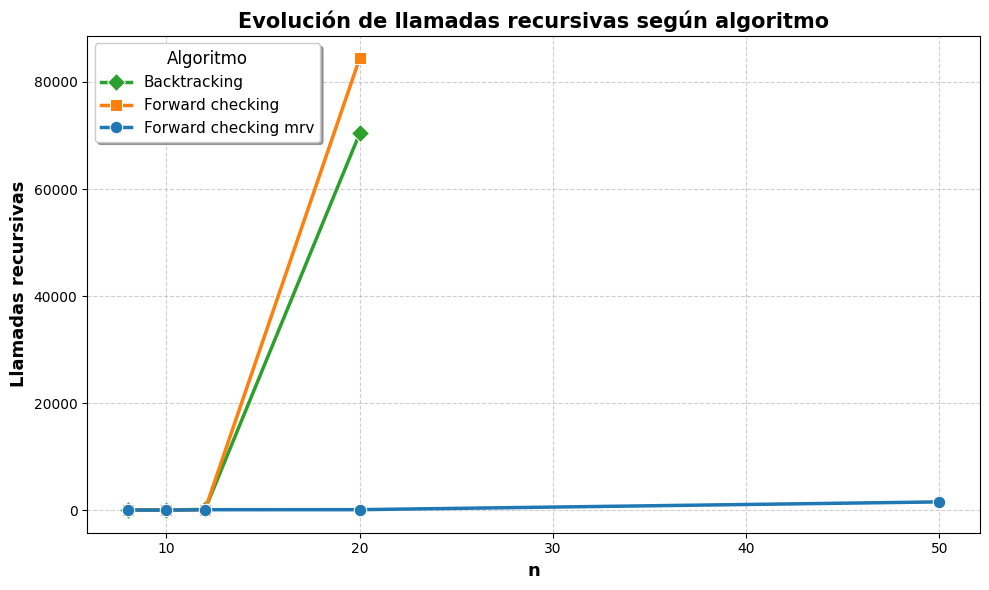

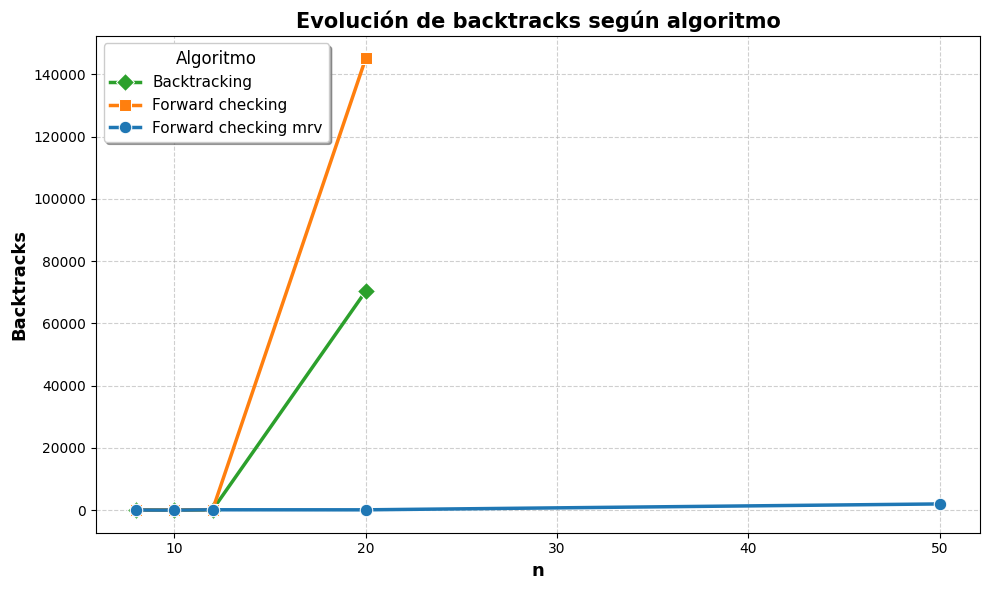

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir marcadores y paleta de colores para cada algoritmo
marcadores = {'forward_checking_MRV': 'o', 'forward_checking': 's', 'backtracking': 'D'}
colores = {'forward_checking_MRV': '#1f77b4', 'forward_checking': '#ff7f0e', 'backtracking': '#2ca02c'}

# Gráfico 1: Tiempo vs n
plt.figure(figsize=(10,6))
for algoritmo, df_alg in dfResultados.groupby("algoritmo"):
    sns.lineplot(
        data=df_alg,
        x="n",
        y="tiempo (ms)",
        label=algoritmo.replace("_", " ").capitalize(),
        marker=marcadores.get(algoritmo, 'o'),
        color=colores.get(algoritmo, None),
        linewidth=2.5,
        markersize=9
    )
plt.xlabel("n", fontsize=13, fontweight='bold')
plt.ylabel("Tiempo (ms)", fontsize=13, fontweight='bold')
plt.title("Evolución del tiempo según algoritmo", fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Algoritmo", fontsize=11, title_fontsize=12, loc='upper left', frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.show()

# Gráfico 2: Llamadas vs n (estandarizado)
plt.figure(figsize=(10,6))
for algoritmo, df_alg in dfResultados.groupby("algoritmo"):
    sns.lineplot(
        data=df_alg,
        x="n",
        y="llamadas",
        label=algoritmo.replace("_", " ").capitalize(),
        marker=marcadores.get(algoritmo, 'o'),
        color=colores.get(algoritmo, None),
        linewidth=2.5,
        markersize=9
    )
plt.xlabel("n", fontsize=13, fontweight='bold')
plt.ylabel("Llamadas recursivas", fontsize=13, fontweight='bold')
plt.title("Evolución de llamadas recursivas según algoritmo", fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Algoritmo", fontsize=11, title_fontsize=12, loc='upper left', frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.show()

# Gráfico 3: Backtracks vs n (estandarizado)
plt.figure(figsize=(10,6))
for algoritmo, df_alg in dfResultados.groupby("algoritmo"):
    sns.lineplot(
        data=df_alg,
        x="n",
        y="backtracks",
        label=algoritmo.replace("_", " ").capitalize(),
        marker=marcadores.get(algoritmo, 'o'),
        color=colores.get(algoritmo, None),
        linewidth=2.5,
        markersize=9
    )
plt.xlabel("n", fontsize=13, fontweight='bold')
plt.ylabel("Backtracks", fontsize=13, fontweight='bold')
plt.title("Evolución de backtracks según algoritmo", fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Algoritmo", fontsize=11, title_fontsize=12, loc='upper left', frameon=True, fancybox=True, shadow=True)
plt.tight_layout()
plt.show()
